In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

from mcp_boltzmann import annihilation as ann
from mcp_boltzmann.boltzmann import Boltzmann

warnings.filterwarnings("ignore")

In [3]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

In [4]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

### MCP model parameters

In [5]:
shelton_Q_mass_027 = load_csv('../input/fig/2206.13530_fig3_DNE_027.csv')
shelton_Q_of_M = interp1d(shelton_Q_mass_027[0], shelton_Q_mass_027[1])

In [6]:
MeV = 1
GeV = 1e3

In [7]:
# m_mcp = 10000.0*MeV
# m_mcp = 100.0*MeV

m_mcp = 2000.0*MeV

Q = shelton_Q_of_M(m_mcp)
# Q = 2.7e-9

c_theta_w = 0.881255
eps_VR = 1e-9

Q = eps_VR/c_theta_w
# Q = eps_VR
# Q = 2e-8

Q = 5e-6

In [8]:
print(f'{Q=}')

Q=5e-06


## Annihilation Collision terms

In [9]:
from mcp_boltzmann.annihilation import load_ann_rate

_CF_ff_xx_I = load_ann_rate(
    f'../output/rates/annihilation/test/mcp_annihilation_rate_m_{m_mcp}_Q_1.npz'
)

In [10]:
#total annihilation rate from sm to dark sector
def CF_ann(T, Q):
    return Q**2*_CF_ff_xx_I(T)

def CF_ann_sm_ds(T_sm, T_ds, Q):
    return CF_ann(T_sm, Q) - CF_ann(T_ds, Q)

## Coulomb Scattering

In [11]:
from mcp_boltzmann.elastic_scattering import load_tabulated_rate

mcp_coulomb_rate = load_tabulated_rate(f'../output/rates/coulomb/cluster/mcp_coulomb_rate_m_{m_mcp}_Q_1.npz')
mcp_coulomb_rate_F = load_tabulated_rate(f'../output/rates/coulomb/cluster/mcp_coulomb_rate_m_{m_mcp}_Q_1_F.npz')

In [12]:
def CF_scatt_sm_ds(T_sm, T_ds, Q):
    return Q**2*mcp_coulomb_rate(T_sm, T_ds)

def CF_scatt_sm_ds_F(T_sm, T_ds, Q):
    return Q**2*mcp_coulomb_rate_F(T_sm, T_ds)

## Plasmon Decay

In [13]:
from mcp_boltzmann import plasma as plas
def CF_plas(T_sm, T_ds, Q):
    T_EW = 160*GeV
    pdecay = np.heaviside(T_EW - T_sm, 0)*plas.C_plasmon(T_sm, T_ds, m_mcp, Q) 
    bdecay = np.heaviside(T_sm - T_EW, 1)*plas.C_B_decay(T_sm, T_ds, m_mcp, Q)
    return pdecay + bdecay

### Z decay

In [14]:
def CF_Z_decay(T_sm, T_ds, Q):
    return plas.C_Z_decay(T_sm, T_ds, m_mcp, Q)

# Setup Boltzmann equation

In [15]:
Boltz = Boltzmann(m_mcp, Q)
Boltz.add_colterm_EM_DS(CF_ann_sm_ds)
# Boltz.add_colterm_EM_DS(CF_scatt_sm_ds)
Boltz.add_colterm_EM_DS(CF_plas)
Boltz.add_colterm_EM_DS(CF_Z_decay)

In [16]:
from mcp_boltzmann.sm import DeltaRho_nue, DeltaRho_numu

FAC = 1./(6.58212e-22)

def delta_rho_nu_gam(T_gam, T_nu):
    return (1/FAC)*(DeltaRho_nue(T_gam, T_nu, 0.0) + 2*DeltaRho_numu(T_gam, T_nu, 0.0))

In [17]:
T_gamma_0 = 1e6 * MeV
T_nu_0 = T_gamma_0
T_DS_0 = 1e3
# T_DS_0 = 1e6

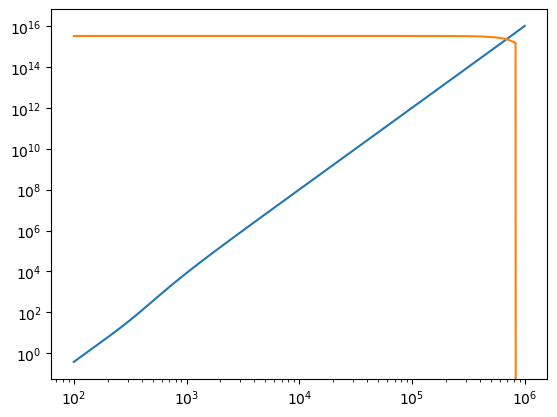

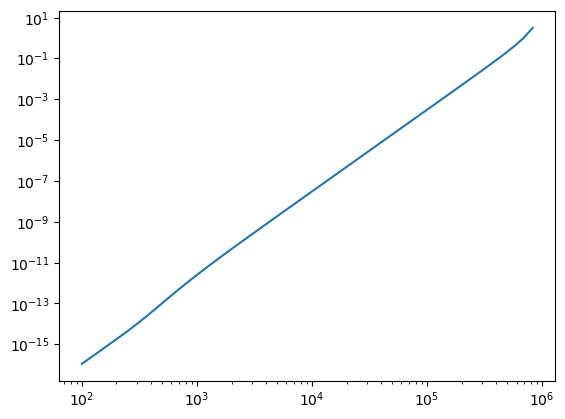

In [18]:
from mcp_boltzmann import boltzmann
from mcp_boltzmann.boltzmann import rho_DS
T_DS_test = np.geomspace(1e2, 1e6)

4*boltzmann.Hubble(T_gamma_0, T_gamma_0, T_DS_0, m_mcp)*rho_DS(T_DS_0, m_mcp)
Boltz.colterm_EM_DS(T_gamma_0, T_DS_0)

plt.plot(T_DS_test, 4*boltzmann.Hubble(T_gamma_0, T_gamma_0, T_DS_test, m_mcp)*rho_DS(T_DS_test, m_mcp))
plt.plot(T_DS_test, Boltz.colterm_EM_DS(T_gamma_0, T_DS_test))
plt.yscale('log')
plt.xscale('log')
plt.show()

R = 4*boltzmann.Hubble(T_gamma_0, T_gamma_0, T_DS_test, m_mcp)*rho_DS(T_DS_test, m_mcp)/Boltz.colterm_EM_DS(T_gamma_0, T_DS_test)

plt.plot(T_DS_test, R)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [19]:
sol_sm = Boltz.solve_boltzmann_eq_SM(10, 10)

time_sm = sol_sm[0]
T_gam_sm = sol_sm[1]
T_nu_sm = sol_sm[2]
sf_sm = sol_sm[3]

Boltz.N_eff_SM(T_gam_sm[-1], T_nu_sm[-1])

3.011027677950294

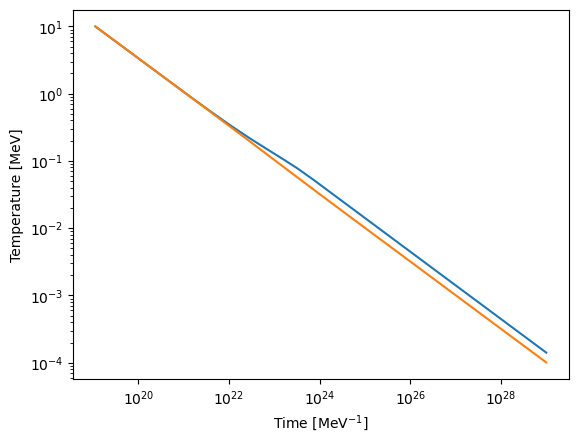

In [20]:
plt.plot(time_sm, T_gam_sm)
plt.plot(time_sm, T_nu_sm)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Time [MeV$^{-1}$]')
plt.ylabel('Temperature [MeV]')

plt.show()

In [21]:
sol_bsm = Boltz.solve_boltzmann_eq_L(T_gamma_0, T_nu_0, T_DS_0)

time_bsm = sol_bsm[0]
T_gam_bsm = sol_bsm[1]
T_nu_bsm = sol_bsm[2]
T_dark_bsm = sol_bsm[3]
sf_bsm = sol_bsm[4]

## Neff

In [22]:
from mcp_boltzmann.boltzmann import rho_DS, rho_EM, rho_neutrino

def Delta_Neff_lazy(T_gam, T_ds, m_mcp):
    return (8/7)*(11/4)**(4/3)*(rho_DS(T_ds, m_mcp)/rho_EM(T_gam))

In [23]:
print(Delta_Neff_lazy(T_gam_bsm[-1], T_dark_bsm[-1], m_mcp))

[0.14075861]


In [24]:
N_eff_bsm = Boltz.N_eff(T_gam_bsm[-1], T_nu_bsm[-1], T_dark_bsm[-1])
N_eff_sm = Boltz.N_eff_SM(T_gam_sm[-1], T_nu_sm[-1])
Delta_Neff = N_eff_bsm - N_eff_sm 

In [25]:
print(f'{N_eff_sm=}')
print(f'{N_eff_bsm=}')
print(f'{Delta_Neff=}')

N_eff_sm=3.011027677950294
N_eff_bsm=array([3.16428031])
Delta_Neff=array([0.15325263])


## Temperature Evolution

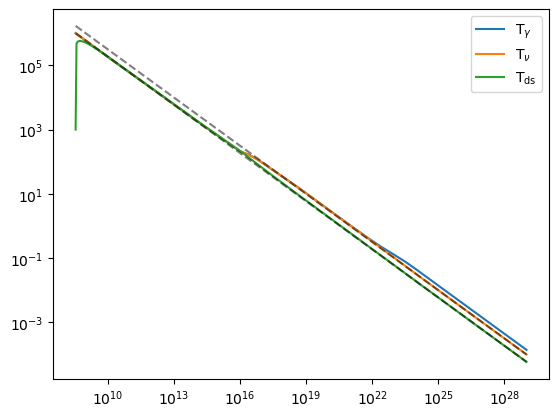

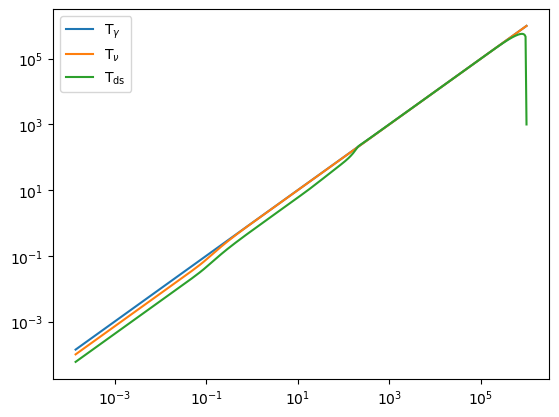

In [26]:
plt.plot(time_bsm, T_gam_bsm, label=r'T$_\gamma$')
plt.plot(time_bsm, T_nu_bsm, label=r'T$_{\nu}$')
plt.plot(time_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')

plt.plot(time_bsm, T_gam_bsm[0]*np.sqrt(time_bsm[0]/time_bsm), linestyle='dashed', color='black', alpha=0.5)
plt.plot(time_bsm, T_nu_bsm[-1]*np.sqrt(time_bsm[-1]/time_bsm), linestyle='dashed', color='black', alpha=0.5)

plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


plt.plot(T_gam_bsm, T_gam_bsm, label=r'T$_\gamma$')
plt.plot(T_gam_bsm, T_nu_bsm, label=r'T$_{\nu}$')
plt.plot(T_gam_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')


plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


In [27]:
fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig3_left_Td_by_Tgam.csv')

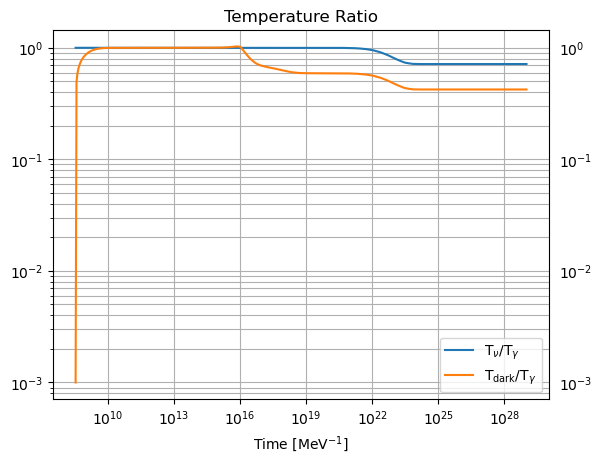

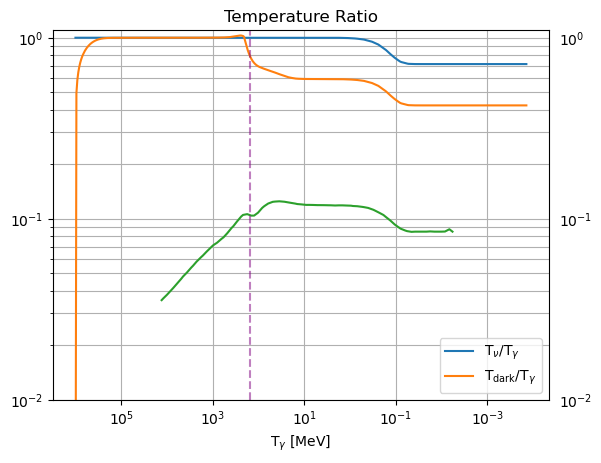

In [28]:
plt.plot(time_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$')
plt.plot(time_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm dark}$/T$_\gamma$')
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Time [MeV$^{-1}$]')
plt.title('Temperature Ratio')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')

plt.legend()

plt.show()

plt.plot(T_gam_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$')
plt.plot(T_gam_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm dark}$/T$_\gamma$')
plt.plot(*fig3_1311_2600_Td_by_Tgam)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('T$_\gamma$ [MeV]')
plt.title('Temperature Ratio')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')
plt.gca().invert_xaxis()


plt.ylim(1e-2, 1.1)
# plt.axvline(200,  color='purple', linestyle='dashed', alpha=0.5, label=r'$\Lambda_{\rm QCD}$')
plt.axvline(150,  color='purple', linestyle='dashed', alpha=0.5)
# plt.xlim(0.8e4, 1.1e-2)
plt.legend()

plt.show()

In [29]:
from mcp_boltzmann.boltzmann import Hubble
# Hub_plot = Hubble(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)
# plt.plot(time_bsm, np.abs(CF_plas(T_gam_bsm, T_dark_bsm, Q)/Hub_plot), label='Plasmon Decay')
# plt.plot(time_bsm, np.abs(CF_ann_sm_ds(T_gam_bsm, T_dark_bsm, Q)/Hub_plot), label='Annihilation')
# plt.plot(time_bsm, np.abs(CF_scatt_sm_ds(T_gam_bsm, T_dark_bsm, Q)/Hub_plot), label='Scattering')
# plt.plot(time_bsm, np.abs(CF_Z_decay(T_gam_bsm, T_dark_bsm, Q)/Hub_plot), label='Z boson decay')

# plt.legend()
# plt.yscale('log')
# plt.xscale('log')

# plt.ylabel(r'Rate')
# plt.xlabel(r'Time [MeV$^{-1}$]')

# plt.ylim(1e-5, 1e20)

# plt.show()

In [30]:
# plt.plot(T_gam_bsm, CF_plas(T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='plasmon decay')
# plt.plot(T_gam_bsm, CF_Z_decay(T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='Z decay')
# plt.plot(T_gam_bsm, CF_ann_sm_ds(T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='annihilation')
# plt.plot(T_gam_bsm, CF_scatt_sm_ds(T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='scattering')
# plt.ylim(1e-28, 1e-22)

# plt.axvline(200,  color='purple', linestyle='dashed', alpha=0.5, label=r'$\Lambda_{\rm QCD}$')
# plt.axvline(m_mcp, color='black', linestyle='dotted', label=r'$m_{\rm mcp}$')

# plt.yscale('log')
# plt.xscale('log')

# plt.legend(loc='upper right')
# plt.gca().invert_xaxis()

# plt.xlabel(r'T$_\gamma$ [MeV]')
# plt.ylabel(r'C/$T^6_\gamma$ [MeV$^{-1}$]')
# plt.show()

In [31]:
Col_tot = (
    CF_ann_sm_ds(T_gam_bsm, T_dark_bsm, Q)
   +CF_plas(T_gam_bsm, T_dark_bsm, Q)
)

Hub_tot = boltzmann.Hubble(T_gam_bsm, T_nu_bsm,T_dark_bsm, m_mcp)*(
    boltzmann.rho_DS(T_dark_bsm, m_mcp) + boltzmann.p_DS(T_dark_bsm, m_mcp)
)
            

In [32]:
com_ED = boltzmann.rho_DS(T_dark_bsm, m_mcp)*(sf_bsm)**4
# com_col = Boltz.colterm_EM_DS(T_gam_bsm, T_dark_bsm)*(sol_bsm.y[3])**4
# com_col = CF_ann(T_gam_bsm, Q)*(sol_bsm.y[3])**4
# com_col = (
#     CF_scatt_sm_ds_F(T_gam_bsm, T_dark_bsm, Q)
#    +CF_ann(T_gam_bsm, Q)
#    +plas.C_plasmon_forwards(T_gam_bsm, m_mcp, Q)
# )*(sf_bsm)**4

com_col = (
   +CF_ann(T_gam_bsm, Q)
   +plas.C_plasmon_forwards(T_gam_bsm, m_mcp, Q)
)*(sf_bsm)**4

H_plot = Hubble(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)

In [33]:
# shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_left_energy.csv')
# shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_right_energy.csv')
# shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

## We need to plot the forward energy transfer term here, which needs to be computed for elastic scattering

In [34]:
#compute comoving energy density for DeltaNeff = 0.3s

In [35]:
#calculation of dark sector temp that makes Delta N_eff = 0.3 at Tsm = 1e-3 MeV
r = 0.3*(7/8)*(4/11)**(4/3)*boltzmann.rho_EM(1e-3)
T_ds_03 = ((15/np.pi**2)*r)**(1/4)

sf = sf_bsm[find_nearest(T_gam_bsm, 1e-3)]

rho_neff_03 = boltzmann.rho_DS(T_ds_03, m_mcp)*(sf)**4

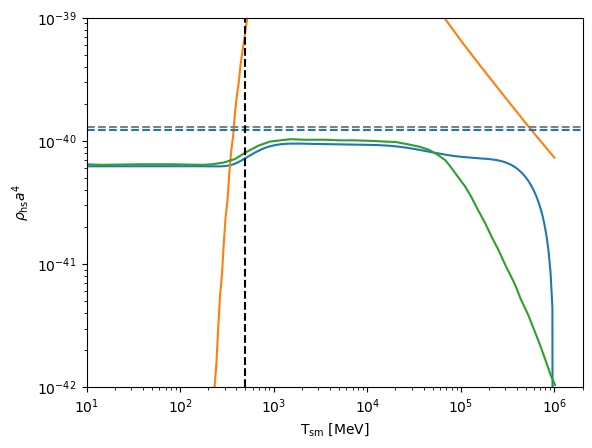

In [36]:
plt.plot(T_gam_bsm, com_ED)
plt.plot(T_gam_bsm, com_col/H_plot)
plt.plot(*shelton_f2_rho)
# plt.plot(*shelton_f2_cF)

plt.axhline(rho_neff_03, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed')
plt.axhline(1.3e-40, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed', color='gray')

plt.yscale('log')
plt.xscale('log')
plt.axvline(m_mcp/4, linestyle='dashed', color='black')

plt.xlabel(r'T$_{\rm sm}$ [MeV]')
plt.ylabel(r'$\rho_{\rm hs} a^4$')

plt.ylim(1e-42, 1e-39)
# plt.xlim(3, 1e4)
plt.xlim(10, 2e6)
plt.show()

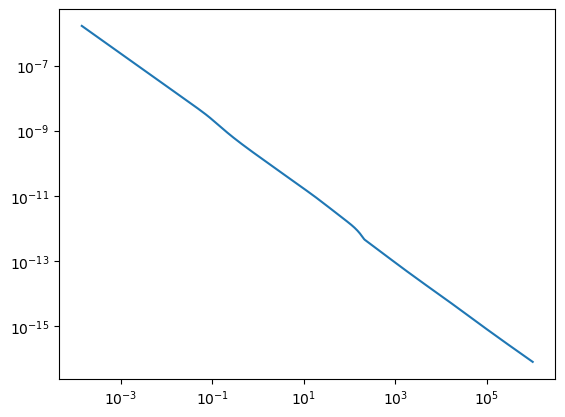

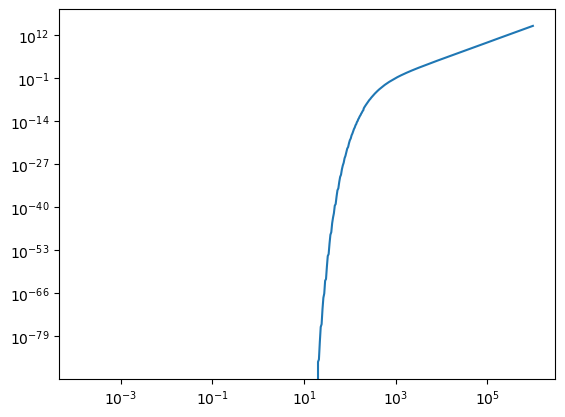

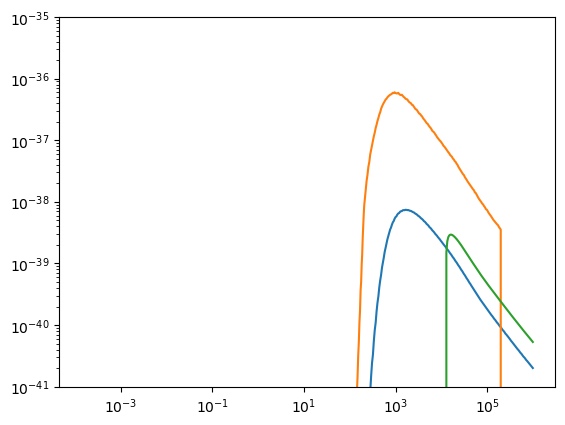

In [37]:
plt.plot(T_gam_bsm, sf_bsm)
plt.yscale('log')
plt.xscale('log')
plt.show()

plt.plot(T_gam_bsm, CF_ann(T_gam_bsm, Q))
plt.yscale('log')
plt.xscale('log')
plt.show()

plt.plot(T_gam_bsm, CF_ann(T_gam_bsm, Q)*sf_bsm**4/H_plot)
plt.plot(T_gam_bsm, CF_scatt_sm_ds_F(T_gam_bsm, T_dark_bsm, Q)*sf_bsm**4/H_plot)
plt.plot(T_gam_bsm, plas.C_plasmon_forwards(T_gam_bsm, m_mcp, Q)*sf_bsm**4/H_plot)
plt.yscale('log')
plt.xscale('log')

plt.ylim(1e-41, 1e-35)
plt.show()




In [38]:
rho_tot_bsm = boltzmann.rho_tot_bsm(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)

In [39]:
rho_dot = np.nan_to_num(np.gradient(rho_tot_bsm, time_bsm, edge_order=2))

In [40]:
cont = -3*boltzmann.Hubble(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)*(
    boltzmann.rho_tot_bsm(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)
  + boltzmann.p_tot_bsm(T_gam_bsm, T_nu_bsm, T_dark_bsm, m_mcp)
)

In [41]:
rho_tot_sm = boltzmann.rho_tot_sm(T_gam_sm, T_nu_sm)
cont_sm = -3*boltzmann.Hubble_SM(T_gam_sm, T_nu_sm)*(
    boltzmann.rho_tot_sm(T_gam_sm, T_nu_sm)
  + boltzmann.p_tot_sm(T_gam_sm, T_nu_sm)
)

rho_dot_sm = np.gradient(rho_tot_sm, time_sm)

## Check Continuity

In [42]:
rho_dot_sm/cont_sm

array([0.9339109 , 1.00473161, 1.00493371, 1.00462711, 1.00438656,
       1.00407451, 1.00401121, 1.00408115, 1.0042524 , 1.00446054,
       1.00447505, 1.0043873 , 1.00431207, 1.00425952, 1.00423388,
       1.00420324, 1.00425127, 1.00439604, 1.00438428, 1.00427712,
       1.00423016, 1.004271  , 1.00431269, 1.00432192, 1.00429771,
       1.00426457, 1.00426705, 1.00429669, 1.0042974 , 1.00427628,
       1.0042419 , 1.00426834, 1.00434385, 1.00434507, 1.0043538 ,
       1.00433434, 1.00427791, 1.00426548, 1.0042818 , 1.00429071,
       1.00428238, 1.00426278, 1.00425103, 1.00427038, 1.00431201,
       1.00431891, 1.00428218, 1.00430025, 1.00437941, 1.00437639,
       1.00432152, 1.00431109,        nan,        nan, 1.08464965,
       1.04729564, 1.00717467, 1.00492652, 0.99921965, 0.99985195,
       0.99988978, 0.99983438, 0.99998976, 0.99999144, 1.00000023,
       0.99999959, 0.99999998, 1.00000008, 0.99999999, 0.99999999,
       0.99999993, 0.99999988, 0.99999933, 0.99999879, 0.99999

In [43]:
rho_dot/cont

array([ 0.97107255,  1.01786811,  1.01786844,  1.0178591 ,  1.01785257,
        1.01786462,  1.0178731 ,  1.017798  ,  1.01766577,  1.01765164,
        1.01772458,  1.01768293,  1.01767155,  1.01789211,  1.01812778,
        1.01816798,  1.01791425,  1.01796195,  1.01821268,  1.01825664,
        1.01803403,  1.01791955,  1.01808389,  1.01813045,  1.01808139,
        1.01784964,  1.01804137,  1.01834324,  1.01838598,  1.01790361,
        1.01780082,  1.01804073,  1.01816782,  1.01811861,  1.01763113,
        1.0179224 ,  1.01855348,  1.0188311 ,  1.01779982,  1.01713809,
        1.01750599,  1.01838478,  1.01882139,  1.01757507,  1.018173  ,
        1.01953101,  1.02023797,  1.01868554,  1.0170399 ,  1.01768021,
        1.01853894,  1.01841949,  1.01702836,  1.01742794,  1.01696659,
        1.01610359,  1.01729802,  1.01736501,  1.01783435,  1.0177825 ,
        1.01732569,  1.01700812,  1.01732165,  1.01768579,  1.01880445,
        1.01955096,  1.01736435,  1.01740434,  1.01859012,  1.01